In [3]:
# Decision Trees — experiment och presentation
# Kör i Jupyter Notebook

# ============================================================
# 1) Importer
# ============================================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [4]:
# ============================================================
# 2) Läs in dataset och förbehandling
# ============================================================
df = pd.read_csv("Pokemon.csv")   # justera filnamn/sökväg om nödvändigt

# Ta bort kolumnerna Type 2 och Legendary (om de finns)
df = df.drop(columns=["Type 2", "Legendary"], errors="ignore")

# Features och målvariabel
features = ['HP','Attack','Defense','Sp. Atk','Sp. Def','Speed','Generation']
X_raw = df[features].copy()
y_raw = df['Type 1'].copy()   # målvariabeln

# Label-encoding av målvariabel (multiklass)
le = LabelEncoder()
y_enc = le.fit_transform(y_raw)
class_labels = le.classes_

# Enkel kontroll
print(f"Dataset: {df.shape[0]} rader, {len(class_labels)} klasser i 'Type 1'")

Dataset: 800 rader, 18 klasser i 'Type 1'


In [5]:
# ============================================================
# 3) Experimentinställningar
# ============================================================
scalings = ['original', 'minmax']   # datavarianter
splits = {
    '90_10': 0.90,
    '70_30': 0.70   # valt "valfritt" förhållande
}
n_repeats = 100  # antal upprepningar per konfiguration

# Container för resultat
results = []  # varje rad: dict med metadata och summerade mått

In [6]:
# ============================================================
# 4) Hjälpfunktion: rita konfusionsmatris (för senare bruk)
# ============================================================
def plot_confusion(cm, labels, title="Confusion matrix", normalize=False, fmt=".2f"):
    plt.figure(figsize=(10,8))
    if normalize:
        cm_sum = cm.sum(axis=1, keepdims=True)
        with np.errstate(all='ignore'):
            cm_norm = cm / cm_sum
        sns.heatmap(cm_norm, annot=True, fmt=fmt, xticklabels=labels, yticklabels=labels, cmap="Blues")
        plt.title(title + " (normaliserad per sann rad)")
    else:
        sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues")
        plt.title(title)
    plt.ylabel("Sanna")
    plt.xlabel("Predikterade")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [7]:
# ============================================================
# 5) Kör experimenten: för varje (scaling × split) kör n_repeats
# ============================================================
for scaling in scalings:
    # Skala data om så önskas
    if scaling == 'minmax':
        scaler = MinMaxScaler()
        X = pd.DataFrame(scaler.fit_transform(X_raw), columns=X_raw.columns)
    else:
        X = X_raw.copy()

    X_arr = X.values

    for split_name, train_size in splits.items():
        accs = []
        cms = []  # spara konfusionsmatriser för varje repetition
        # Utför n_repeats upprepningar
        for i in range(n_repeats):
            # VARNING: random_state lämnas som None för både train_test_split och modellen
            X_train, X_test, y_train, y_test = train_test_split(
                X_arr, y_enc, train_size=train_size, stratify=y_enc, random_state=None
            )

            clf = DecisionTreeClassifier(random_state=None)
            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)

            acc = accuracy_score(y_test, y_pred)
            cm = confusion_matrix(y_test, y_pred, labels=np.arange(len(class_labels)))

            accs.append(acc)
            cms.append(cm)

        # Beräkna medelaccuracy och andra statistikmått
        mean_acc = float(np.mean(accs))
        std_acc = float(np.std(accs))
        median_acc = float(np.median(accs))

        # Spara sista repetitionens konfusionsmatris
        last_cm = cms[-1]

        # Skapa en "medel"-konfusionsmatris genom att summera och normalisera på rader
        sum_cm = np.sum(cms, axis=0)  # summerade counts
        with np.errstate(all='ignore'):
            sum_cm_norm = sum_cm.astype(float) / sum_cm.sum(axis=1, keepdims=True)

        results.append({
            'scaling': scaling,
            'split_name': split_name,
            'train_size': train_size,
            'mean_accuracy': mean_acc,
            'std_accuracy': std_acc,
            'median_accuracy': median_acc,
            'last_accuracy': accs[-1],
            'last_confusion_matrix': last_cm,
            'sum_confusion_matrix': sum_cm,
            'sum_confusion_matrix_norm': sum_cm_norm,
            'all_accuracies': accs
        })

In [8]:
# ============================================================
# 6) Sammanställ och visa resultattabell
# ============================================================
summary_df = pd.DataFrame([{
    'scaling': r['scaling'],
    'split': r['split_name'],
    'train_pct': f"{int(r['train_size']*100)}%",
    'mean_accuracy': round(r['mean_accuracy'], 4),
    'std_accuracy': round(r['std_accuracy'], 4),
    'median_accuracy': round(r['median_accuracy'], 4),
    'last_accuracy': round(r['last_accuracy'], 4)
} for r in results])

# Rangordna efter mean_accuracy
summary_ranked = summary_df.sort_values(by='mean_accuracy', ascending=False).reset_index(drop=True)

print("=== Sammanställning (sorterad efter mean_accuracy) ===")
display(summary_ranked)

=== Sammanställning (sorterad efter mean_accuracy) ===


,scaling,split,train_pct,mean_accuracy,std_accuracy,median_accuracy,last_accuracy
0,minmax,90_10,90%,0.1814,0.0471,0.1750,0.1750
1,original,90_10,90%,0.1700,0.0382,0.1750,0.1000
2,minmax,70_30,70%,0.1692,0.0220,0.1688,0.1958
3,original,70_30,70%,0.1678,0.0219,0.1667,0.1667



=== Topp 3 konfigurationer (baserat på mean_accuracy) ===


,scaling,split,train_pct,mean_accuracy,std_accuracy,median_accuracy,last_accuracy
0,minmax,90_10,90%,0.1814,0.0471,0.1750,0.1750
1,original,90_10,90%,0.1700,0.0382,0.1750,0.1000
2,minmax,70_30,70%,0.1692,0.0220,0.1688,0.1958



--- Top 1 ---
Scaling: minmax, Split: 90_10 (train 90%)
Mean accuracy över 100 körningar: 0.1814  (std = 0.0471)
Konfusionsmatris (sista repetitionen):


,Bug,Dark,Dragon,Electric,Fairy,Fighting,Fire,Flying,Ghost,Grass,Ground,Ice,Normal,Poison,Psychic,Rock,Steel,Water
Bug,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,1,1,2
Dark,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0
Dragon,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
Electric,0,0,0,2,0,0,0,1,0,1,0,0,0,0,0,0,0,0
Fairy,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1
Fighting,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1
Fire,0,0,0,0,0,0,1,0,0,1,0,1,0,0,1,0,0,1
Flying,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Ghost,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0
Grass,0,0,0,0,1,0,0,0,0,1,0,0,0,3,1,1,0,0


Normaliserad medelkonfusionsmatris över alla repetitionerna:


,Bug,Dark,Dragon,Electric,Fairy,Fighting,Fire,Flying,Ghost,Grass,Ground,Ice,Normal,Poison,Psychic,Rock,Steel,Water
Bug,0.234,0.051,0.024,0.050,0.009,0.040,0.031,0.003,0.023,0.050,0.043,0.026,0.113,0.036,0.047,0.064,0.050,0.106
Dark,0.097,0.070,0.037,0.047,0.030,0.040,0.087,0.003,0.050,0.123,0.020,0.020,0.130,0.013,0.037,0.037,0.023,0.137
Dragon,0.060,0.060,0.193,0.023,0.050,0.020,0.063,0.007,0.023,0.040,0.087,0.010,0.097,0.040,0.057,0.043,0.033,0.093
Electric,0.065,0.025,0.015,0.202,0.010,0.022,0.080,0.028,0.040,0.085,0.015,0.068,0.055,0.018,0.122,0.018,0.002,0.130
Fairy,0.065,0.035,0.065,0.020,0.050,0.045,0.055,0.000,0.015,0.060,0.025,0.040,0.025,0.025,0.135,0.040,0.010,0.290
Fighting,0.083,0.050,0.013,0.027,0.017,0.147,0.067,0.000,0.010,0.090,0.110,0.027,0.157,0.033,0.023,0.077,0.017,0.053
Fire,0.030,0.040,0.044,0.110,0.010,0.024,0.200,0.004,0.024,0.144,0.036,0.028,0.042,0.046,0.072,0.020,0.002,0.124
Flying,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ghost,0.073,0.043,0.027,0.067,0.003,0.007,0.053,0.000,0.240,0.100,0.003,0.013,0.047,0.013,0.147,0.047,0.050,0.067
Grass,0.069,0.047,0.033,0.050,0.013,0.027,0.111,0.007,0.034,0.106,0.023,0.039,0.086,0.033,0.077,0.051,0.011,0.183


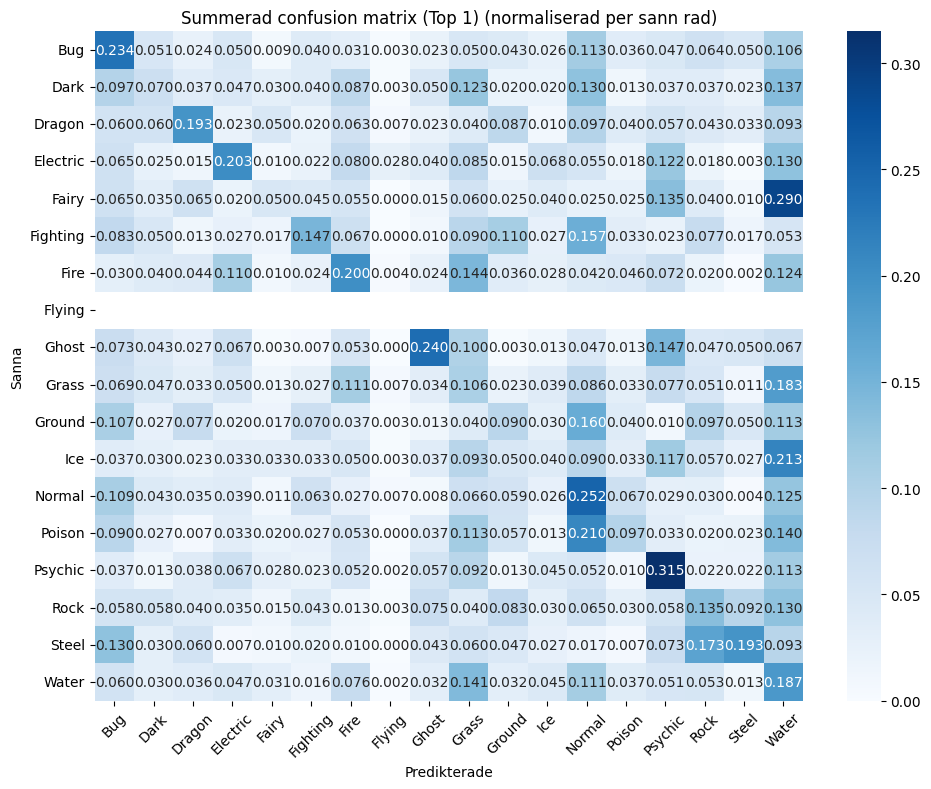


--- Top 2 ---
Scaling: original, Split: 90_10 (train 90%)
Mean accuracy över 100 körningar: 0.1700  (std = 0.0382)
Konfusionsmatris (sista repetitionen):


,Bug,Dark,Dragon,Electric,Fairy,Fighting,Fire,Flying,Ghost,Grass,Ground,Ice,Normal,Poison,Psychic,Rock,Steel,Water
Bug,0,1,0,1,0,0,0,0,1,0,0,0,1,0,0,2,1,0
Dark,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0
Dragon,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
Electric,0,0,0,0,0,0,2,0,0,0,1,0,0,0,1,0,0,0
Fairy,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0
Fighting,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,2,0,0
Fire,0,0,0,1,0,0,1,0,0,2,0,0,0,0,1,0,0,0
Flying,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Ghost,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0
Grass,0,0,0,0,0,0,1,1,0,0,1,1,0,0,1,0,0,2


Normaliserad medelkonfusionsmatris över alla repetitionerna:


,Bug,Dark,Dragon,Electric,Fairy,Fighting,Fire,Flying,Ghost,Grass,Ground,Ice,Normal,Poison,Psychic,Rock,Steel,Water
Bug,0.210,0.049,0.029,0.040,0.004,0.059,0.033,0.006,0.026,0.074,0.047,0.020,0.117,0.046,0.016,0.074,0.054,0.097
Dark,0.080,0.067,0.037,0.067,0.040,0.050,0.090,0.003,0.043,0.083,0.020,0.010,0.140,0.020,0.043,0.063,0.033,0.110
Dragon,0.040,0.043,0.190,0.033,0.017,0.017,0.060,0.017,0.020,0.047,0.057,0.020,0.093,0.023,0.097,0.043,0.043,0.140
Electric,0.058,0.020,0.025,0.195,0.002,0.010,0.122,0.015,0.030,0.085,0.018,0.040,0.080,0.008,0.150,0.038,0.005,0.100
Fairy,0.025,0.065,0.065,0.005,0.080,0.020,0.045,0.000,0.020,0.055,0.020,0.050,0.025,0.035,0.115,0.105,0.015,0.255
Fighting,0.080,0.067,0.020,0.027,0.010,0.110,0.063,0.000,0.013,0.120,0.130,0.030,0.163,0.027,0.033,0.057,0.020,0.030
Fire,0.040,0.050,0.054,0.074,0.014,0.022,0.200,0.008,0.044,0.150,0.010,0.034,0.060,0.030,0.070,0.018,0.004,0.118
Flying,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ghost,0.063,0.030,0.017,0.050,0.010,0.027,0.050,0.003,0.230,0.093,0.020,0.013,0.030,0.023,0.143,0.090,0.033,0.073
Grass,0.071,0.043,0.021,0.063,0.007,0.030,0.116,0.013,0.026,0.080,0.017,0.037,0.080,0.056,0.073,0.046,0.019,0.203


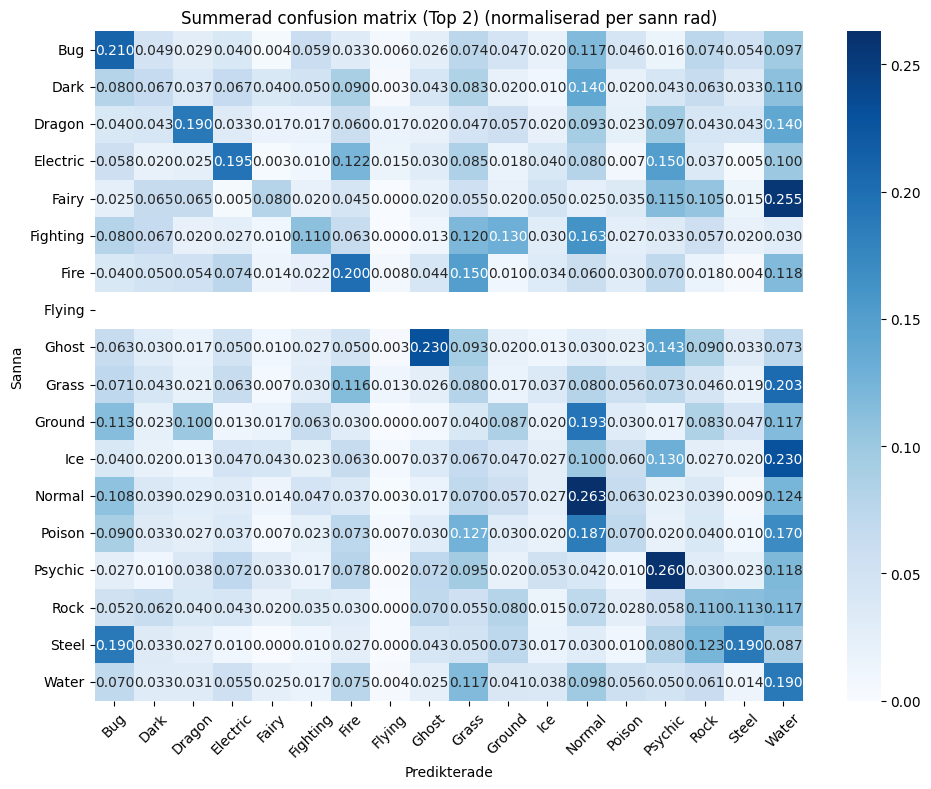


--- Top 3 ---
Scaling: minmax, Split: 70_30 (train 70%)
Mean accuracy över 100 körningar: 0.1692  (std = 0.0220)
Konfusionsmatris (sista repetitionen):


,Bug,Dark,Dragon,Electric,Fairy,Fighting,Fire,Flying,Ghost,Grass,Ground,Ice,Normal,Poison,Psychic,Rock,Steel,Water
Bug,1,5,0,0,0,0,2,0,1,2,0,0,0,3,1,2,0,4
Dark,1,4,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,1
Dragon,0,1,1,0,0,0,0,0,0,0,2,0,1,1,1,0,2,1
Electric,0,0,0,3,0,0,3,0,0,3,1,0,1,0,0,0,0,2
Fairy,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,2
Fighting,0,0,0,0,0,0,1,0,0,2,3,0,1,1,0,0,0,0
Fire,0,1,2,0,0,0,3,0,0,4,0,0,1,1,2,0,0,2
Flying,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
Ghost,0,0,0,0,0,1,0,0,6,1,0,0,1,0,1,0,0,0
Grass,1,0,1,2,0,0,2,0,2,3,0,0,2,1,0,1,0,6


Normaliserad medelkonfusionsmatris över alla repetitionerna:


,Bug,Dark,Dragon,Electric,Fairy,Fighting,Fire,Flying,Ghost,Grass,Ground,Ice,Normal,Poison,Psychic,Rock,Steel,Water
Bug,0.204,0.052,0.025,0.031,0.012,0.041,0.034,0.004,0.024,0.077,0.044,0.016,0.120,0.050,0.038,0.058,0.063,0.107
Dark,0.093,0.070,0.051,0.046,0.040,0.051,0.087,0.006,0.041,0.077,0.029,0.014,0.123,0.026,0.027,0.060,0.027,0.133
Dragon,0.050,0.054,0.201,0.026,0.020,0.027,0.058,0.006,0.018,0.038,0.055,0.021,0.113,0.030,0.079,0.041,0.048,0.115
Electric,0.065,0.023,0.021,0.222,0.007,0.024,0.109,0.022,0.031,0.092,0.014,0.035,0.092,0.008,0.101,0.021,0.005,0.112
Fairy,0.040,0.048,0.066,0.022,0.070,0.040,0.028,0.002,0.022,0.074,0.020,0.046,0.076,0.022,0.136,0.038,0.006,0.244
Fighting,0.104,0.068,0.018,0.025,0.029,0.112,0.056,0.005,0.019,0.081,0.104,0.024,0.159,0.038,0.019,0.051,0.014,0.076
Fire,0.039,0.051,0.037,0.078,0.019,0.029,0.181,0.007,0.026,0.153,0.023,0.031,0.062,0.029,0.072,0.026,0.007,0.129
Flying,0.040,0.020,0.100,0.330,0.020,0.020,0.150,0.070,0.010,0.060,0.000,0.020,0.070,0.000,0.030,0.000,0.000,0.060
Ghost,0.078,0.052,0.021,0.071,0.014,0.012,0.049,0.001,0.206,0.098,0.013,0.027,0.047,0.024,0.116,0.059,0.044,0.068
Grass,0.084,0.039,0.021,0.053,0.014,0.029,0.088,0.005,0.041,0.100,0.020,0.038,0.085,0.046,0.071,0.043,0.027,0.198


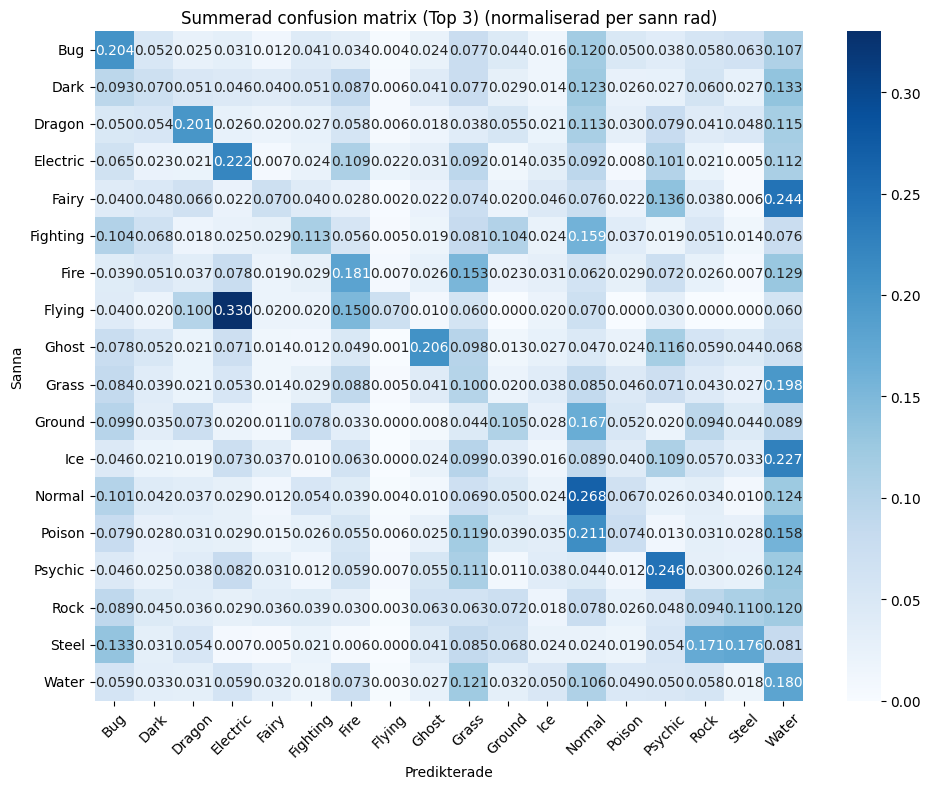

In [9]:
# ============================================================
# 7) Presentera de tre bästa konfigurationerna
# ============================================================
top3 = summary_ranked.head(3)
print("\n=== Topp 3 konfigurationer (baserat på mean_accuracy) ===")
display(top3)

# Hitta motsvarande entries och visa matriser och mått
for idx, row in top3.iterrows():
    match = next(r for r in results if r['scaling']==row['scaling'] and r['split_name']==row['split'])
    print(f"\n--- Top {idx+1} ---")
    print(f"Scaling: {match['scaling']}, Split: {match['split_name']} (train {int(match['train_size']*100)}%)")
    print(f"Mean accuracy över {n_repeats} körningar: {match['mean_accuracy']:.4f}  (std = {match['std_accuracy']:.4f})")
    print("Konfusionsmatris (sista repetitionen):")
    display(pd.DataFrame(match['last_confusion_matrix'], index=class_labels, columns=class_labels))
    print("Normaliserad medelkonfusionsmatris över alla repetitionerna:")
    display(pd.DataFrame(np.round(match['sum_confusion_matrix_norm'], 3), index=class_labels, columns=class_labels))
    plot_confusion(match['sum_confusion_matrix'], class_labels,
                   title=f"Summerad confusion matrix (Top {idx+1})", normalize=True, fmt=".3f")

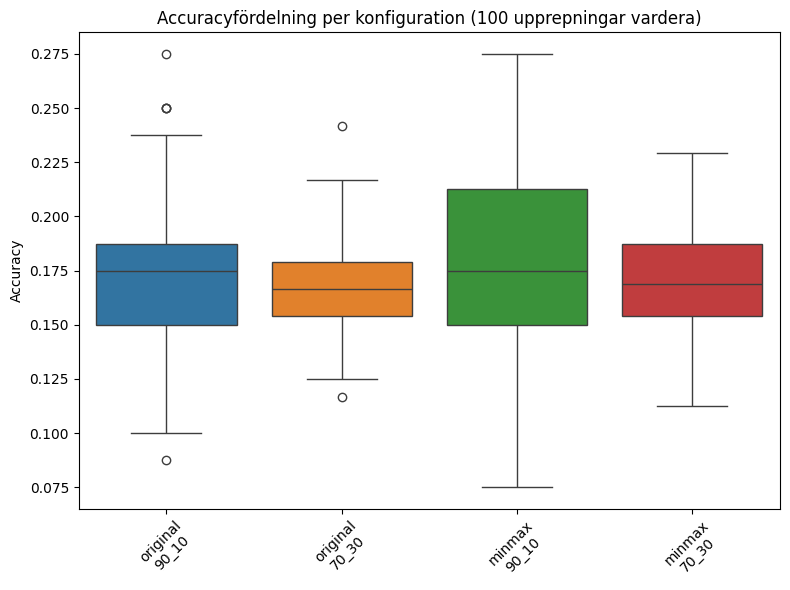

In [10]:
# ============================================================
# 8) Extra: visa fördelning av accuracy (boxplot)
# ============================================================
plt.figure(figsize=(8,6))
acc_data = [r['all_accuracies'] for r in results]
labels_box = [f"{r['scaling']}\n{r['split_name']}" for r in results]
sns.boxplot(data=acc_data)
plt.xticks(ticks=np.arange(len(labels_box)), labels=labels_box, rotation=45)
plt.ylabel("Accuracy")
plt.title("Accuracyfördelning per konfiguration (100 upprepningar vardera)")
plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# 9) Spara resultat till CSV
# ============================================================
summary_ranked.to_csv("decision_tree_experiment_summary.csv", index=False)
print("Resultattabell sparad till 'decision_tree_experiment_summary.csv' (om rättigheter finns).")

Resultattabell sparad till 'decision_tree_experiment_summary.csv' (om rättigheter finns).
